# ViT NES experiments

This notebook tests the project's multi-output Flax Vision Transformer (`model="vit"`). It preserves the usual workflow: train → save JSON → plot later.

The local ViT is a multi-head adapter of the architecture shown in NetKet's ViT wave-function tutorial. It currently supports **2D** TFIM and toric-code inputs.

In [2]:
import sys
from pathlib import Path

# Works when Jupyter is launched from the project root or notebooks/.
cwd = Path.cwd()
PROJECT_ROOT = Path.home() / "Desktop" / "Master Thesis" / "NES_Spins"
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import jax
import jax.numpy as jnp
from nes_lattice.models import ModelSpec, init_model, apply_model
from nes_lattice.train import TrainConfig, train, save_history
from nes_lattice.plots import plot_history, plot_diagnostics, print_final

print("JAX devices:", jax.devices())
print("Project root:", PROJECT_ROOT)

JAX devices: [CudaDevice(id=0)]
Project root: /home/a/Anas.Roumeih/Desktop/Master Thesis/NES_Spins


## 1. ViT interface smoke test

The ViT receives flat spin configurations, reshapes them into 2D patches internally, and returns one real amplitude for each NES state.

In [2]:
spec = ModelSpec(
    model="vit",
    shape=(4, 4),
    k=2,
    n_sites=16,
    input_channels=1,
    vit_patch_size=2,
    vit_d_model=32,
    vit_num_layers=2,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    dtype="float32",
)

params0 = init_model(jax.random.PRNGKey(0), spec)
test_spins = 2 * jax.random.bernoulli(jax.random.PRNGKey(1), 0.5, (5, 16)).astype(jnp.int8) - 1
psi = apply_model(params0, test_spins, spec)

print("input shape:", test_spins.shape)
print("output shape:", psi.shape)
print("all finite:", bool(jnp.all(jnp.isfinite(psi))))
print(psi)

input shape: (5, 16)
output shape: (5, 2)
all finite: True
[[1.7791525  5.20944   ]
 [1.4326271  0.66110504]
 [5.892685   1.4197489 ]
 [1.0418124  1.3479122 ]
 [0.2284495  0.30575812]]


## 2. Small correctness run: 2x2 TFIM

This is cheap enough for exact span evaluation. It is a smoke test for the sampler, ViT wrapper, JSON output, and plotting pipeline.

In [3]:
cfg = TrainConfig(
    shape=(2, 2),
    hamiltonian="tfim",
    k=2,
    J=1.0,
    g=1.0,
    pbc = False,
    model="vit",
    vit_patch_size=1,
    vit_d_model=32,
    vit_num_layers=2,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    steps=2000,
    lr=5e-4,
    n_chains=64,
    n_samples=8,
    print_every=100,
    eval_exact_if_sites_leq=12,
    reference="auto",
    seed=0,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_tfim_2x2_k2_vit.json"
save_history(history, save_path, cfg)
print("saved to:", save_path)

KeyboardInterrupt: 

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project/results/sampled_nes_tfim_2x2_k2_vit.json
Config:             {'shape': [2, 2], 'hamiltonian': 'tfim', 'k': 2, 'J': 1.0, 'g': 1.0, 'Je': None, 'Jm': None, 'pbc': False, 'magnetization': None, 'model': 'vit', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'vit_patch_size': 1, 'vit_d_model': 32, 'vit_num_layers': 2, 'vit_num_heads': 4, 'vit_mlp_ratio': 2, 'vit_use_positional_embeddings': True, 'vit_log_amplitude_clip': 20.0, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 2000, 'lr': 0.0005, 'n_chains': 64, 'n_samples': 8, 'sweep_steps': 4, 'burn_in': 40, 'grad_clip': 10.0, 'print_every': 100, 'eval_exact_if_sites_leq': 12, 'eval_samples': 32, 'eval_chains': 128, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 0}
Final NES energies: [-5.226241509211532, -4.828418993708625]
Reference:          [-5.2262518595055045, -4.8284271

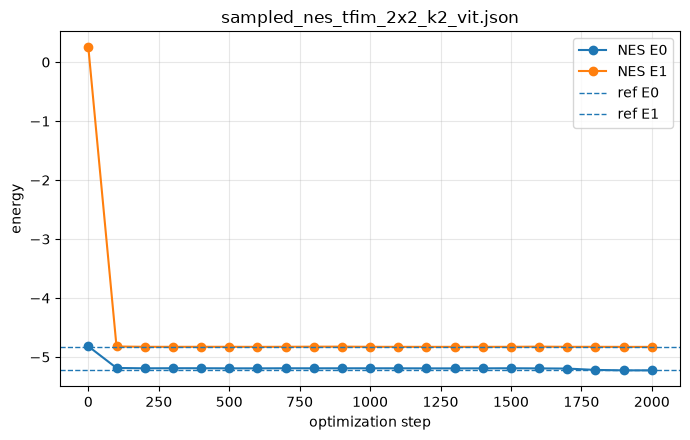

In [6]:
print_final(save_path)
fig, ax = plot_history(save_path)

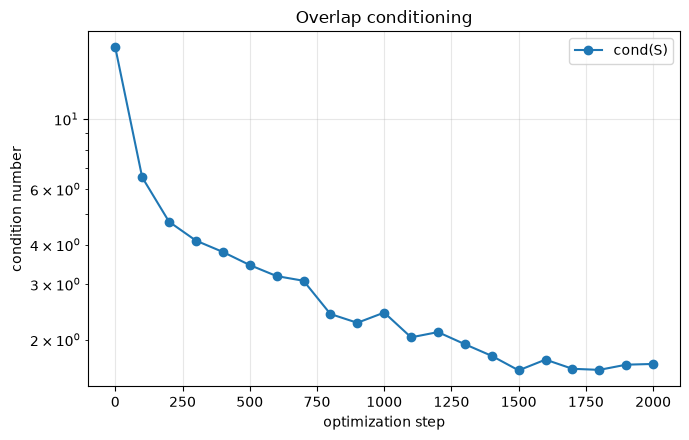

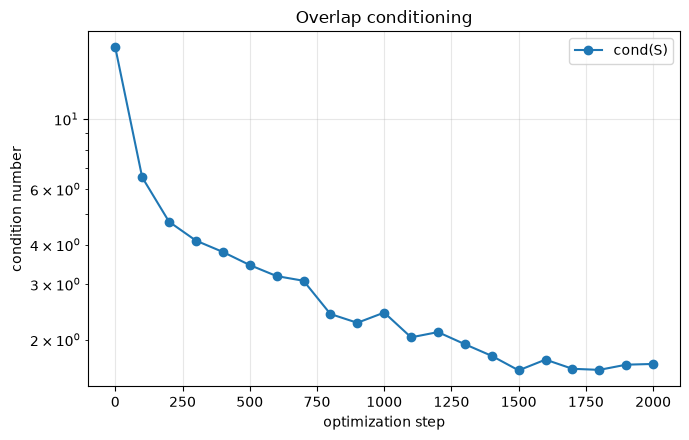

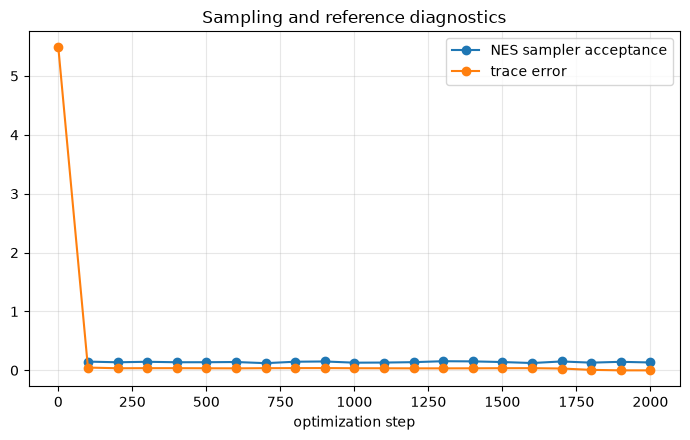

In [7]:
(fig_cond, ax_cond), (fig_diag, ax_diag) = plot_diagnostics(save_path)
fig_cond

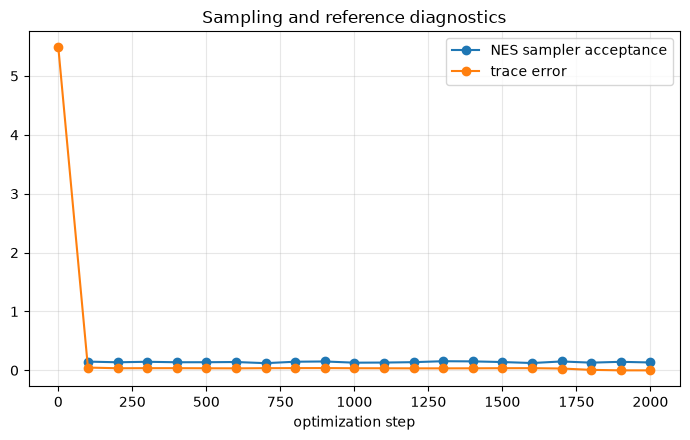

In [8]:
fig_diag

## 3. Main 2D TFIM run: 4x4

`4x4` has 16 spins, so the notebook uses sampled span evaluation by setting `eval_exact_if_sites_leq=12`. Start here after the 2x2 smoke test works.

In [9]:
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian="tfim",
    k=2,
    J=1.0,
    g=1.0,
    model="vit",
    vit_patch_size=2,
    vit_d_model=64,
    vit_num_layers=2,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=True,
    steps=5000,
    lr=5e-4,
    n_chains=128,
    n_samples=8,
    print_every=100,
    eval_exact_if_sites_leq=12,
    eval_chains=128,
    eval_samples=32,
    reference="auto",
    seed=1,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_tfim_4x4_k2_vit.json"
save_history(history, save_path, cfg)
print("saved to:", save_path)

{'step': 0, 'loss_sum': -24.441058529623596, 'train_energy_estimator': nan, 'energies': [-14.278377261774889, -10.162681267848708], 'reference': [-34.010597550846256, -34.01059699946822], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [19.732220289071368, 23.847915731619512], 'trace_error': 43.58013602069088, 'condition_number_S': 4.654208425047788, 'sampler_accept_rate': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.4698944091796875, 'burn_accept_rate': 0.505078136920929, 'S_min_eig': 0.17685941863607715, 'S_max_eig': 0.8231405962650841, 'S_rank': 2, 'S_floor': 1e-06, 'S_num_clipped': 0, 'S_eigenvalues': [0.17685941863607715, 0.8231405962650841], 'method': 'sampled_span_q'}}
{'step': 100, 'loss_sum': -67.95829710927997, 'train_energy_estimator': -68.00303649902344, 'energies': [-33.991329369478066, -33.9669677398019], 'reference': [-34.010597550846256, -34.01059699946822], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [0.019268181368

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project/results/sampled_nes_tfim_4x4_k2_vit.json
Config:             {'shape': [4, 4], 'hamiltonian': 'tfim', 'k': 2, 'J': 1.0, 'g': 1.0, 'Je': None, 'Jm': None, 'pbc': True, 'magnetization': None, 'model': 'vit', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'vit_patch_size': 2, 'vit_d_model': 64, 'vit_num_layers': 2, 'vit_num_heads': 4, 'vit_mlp_ratio': 2, 'vit_use_positional_embeddings': True, 'vit_log_amplitude_clip': 20.0, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 5000, 'lr': 0.0005, 'n_chains': 128, 'n_samples': 8, 'sweep_steps': 16, 'burn_in': 160, 'grad_clip': 10.0, 'print_every': 100, 'eval_exact_if_sites_leq': 12, 'eval_samples': 32, 'eval_chains': 128, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 1}
Final NES energies: [-34.018439491876244, -34.001811779312945]
Reference:          [-34.010597550846256, -34.01

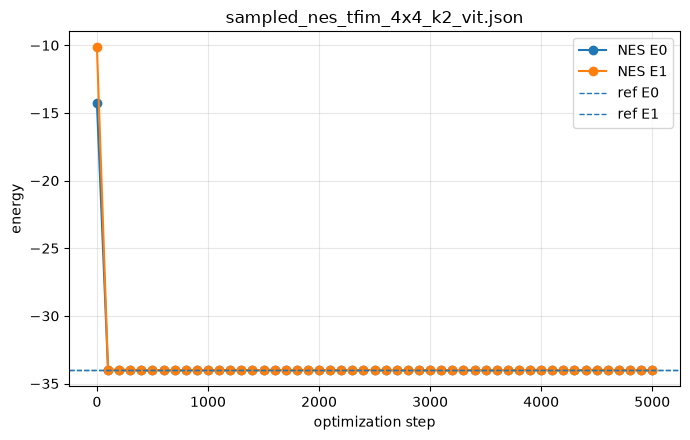

In [10]:
print_final(save_path)
fig, ax = plot_history(save_path)

In [ ]:
(fig_cond, ax_cond), (fig_diag, ax_diag) = plot_diagnostics(save_path)
fig_cond

In [ ]:
fig_diag

## Notes

- `vit_patch_size` must divide both dimensions. For a `3x3` lattice use `vit_patch_size=1`.
- Start with `vit_d_model=64`, `vit_num_layers=2`, `vit_num_heads=4`.
- Use a lower learning rate than the CNN baseline: begin with `5e-4`; try `2e-4` if the determinant sampler becomes unstable.
- The ViT returns positive real amplitudes, which is appropriate for the stoquastic TFIM and toric-code tests in this project.

In [ ]:
cfg = TrainConfig(
    shape=(2, 2),
    hamiltonian="toric_code",
    k=1,
    Je=1.0,
    Jm=1.0,

    model="vit",
    vit_patch_size=1,                  # important
    vit_d_model=64,
    vit_num_layers=4,
    vit_num_heads=4,
    vit_mlp_ratio=2,
    vit_use_positional_embeddings=False,

    steps=4000,
    lr=5e-4,
    grad_clip=1.0,

    n_chains=256,
    n_samples=16,
    print_every=200,

    eval_exact_if_sites_leq=12,
    eval_chains=256,
    eval_samples=64,
    reference="auto",
    seed=1,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_toric_4x4_k1_vit.json"
save_history(history, save_path, cfg)
print("saved to:", save_path)

{'step': 0, 'loss_sum': -1.8663446333117044, 'train_energy_estimator': nan, 'energies': [-1.8663446333117044], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [6.133655366688296], 'trace_error': 6.133655366688296, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'eval': {'S_min_eig': 752.0571899414062, 'S_max_eig': 752.0571899414062, 'S_rank': 1, 'S_floor': 1e-06, 'S_num_clipped': 0, 'S_eigenvalues': [752.0571899414062], 'method': 'exact_span', 'accept_rate': None}}


KeyboardInterrupt: 

: 

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project/results/sampled_nes_toric_4x4_k1_vit.json
Config:             {'shape': [4, 4], 'hamiltonian': 'toric_code', 'k': 1, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'vit', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'vit_patch_size': 1, 'vit_d_model': 64, 'vit_num_layers': 4, 'vit_num_heads': 4, 'vit_mlp_ratio': 2, 'vit_use_positional_embeddings': False, 'vit_log_amplitude_clip': 20.0, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 4000, 'lr': 0.0005, 'n_chains': 256, 'n_samples': 16, 'sweep_steps': 32, 'burn_in': 320, 'grad_clip': 1.0, 'print_every': 200, 'eval_exact_if_sites_leq': 12, 'eval_samples': 64, 'eval_chains': 256, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 1}
Final NES energies: [-16.039947509765625]
Reference:          [-32.0]
Reference source:   toric_code_exac

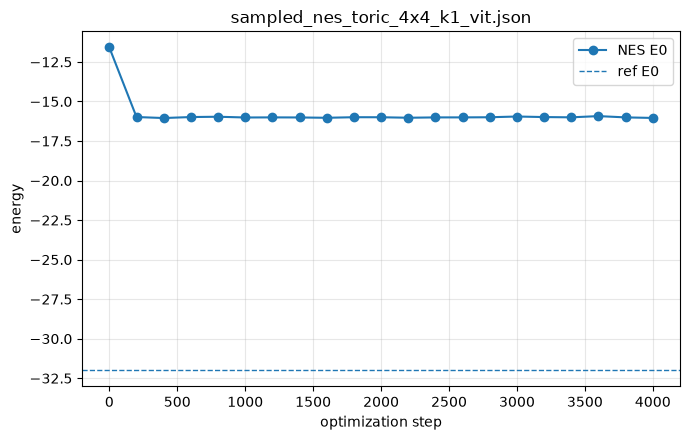

In [23]:
print_final(save_path)
fig, ax = plot_history(save_path)